# OLID2019
## 可学习参数：boost_param(全局，每层单独学习)
### boost_param学习曲线

In [2]:
#下载函数
import pandas as pd
from sklearn.model_selection import train_test_split
from transformers import BertModel, BertTokenizer,BertConfig
from sklearn.metrics import confusion_matrix, classification_report
from transformers import BertTokenizer, BertConfig, Trainer, TrainingArguments
from transformers import BertForSequenceClassification
import numpy as np
import evaluate
import torch
import torch.nn as nn
import math
#本地函数
from MyBertSelfAttention_alltoken import MyBertSelfAttention, MyBertEncoder, MyBertLayer, MyBertModel, MyBertForSequenceClassification

# 数据下载，预处理（Olid or White supremacist）

### 加载olid

In [7]:
###### 数据处理 训练集和测试集分类
label_map = {
    "NOT":0,
    "OFF":1
}
# 读取 CSV
# olid-training中只有13000件推文
df = pd.read_csv('olid-training-v1.0.tsv',sep='\t',usecols=["tweet","subtask_a"])
df.rename(columns={"subtask_a":"label"},inplace=True)
df["label"] = df["label"].map(label_map)

# 打乱
df = df.sample(frac=1).reset_index(drop=True)
# 拆分训练集和测试集.testsize 0.2
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

from datasets import Dataset
train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

### 加载supremacist forum

In [4]:
import os, glob
import pandas as pd
from datasets import Dataset, Value

ROOT = os.path.expanduser("~/test/hate-speech-dataset-master")
ALL_DIR  = os.path.join(ROOT, "all_files")
TEST_DIR = os.path.join(ROOT, "sampled_test")
CSV_PATH = os.path.join(ROOT, "annotations_metadata.csv")  # ←改成你真实文件名

# 1) 读标注表
df = pd.read_csv(CSV_PATH)

# 自动找到 label 列（优先叫 label；否则用最后一列）
label_col = "label" if "label" in df.columns else df.columns[-1]

# 统一类型
df["file_id"] = df["file_id"].astype(str)
df[label_col] = df[label_col].astype(str)

# 2) label -> int（0/1）
label_map = {"noHate": 0, "hate": 1}
df["label"] = df[label_col].map(label_map)

# 丢掉没映射成功的行（比如有空值/拼写不同）
df = df.dropna(subset=["label"]).copy()
df["label"] = df["label"].astype("int64")

# 3) 读文本：每个 file_id 对应 all_files/file_id.txt
def read_txt(file_id: str) -> str:
    path = os.path.join(ALL_DIR, f"{file_id}.txt")
    if not os.path.exists(path):
        return ""
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        return f.read().strip()

df["tweet"] = df["file_id"].apply(read_txt)
df = df[df["tweet"].str.len() > 0].reset_index(drop=True)

# 4) 用 sampled_test 里的文件名做 test split
test_stems = set(os.path.splitext(os.path.basename(p))[0]
                 for p in glob.glob(os.path.join(TEST_DIR, "*.txt")))

is_test = df["file_id"].isin(test_stems)
train_df = df[~is_test][["tweet", "label"]].reset_index(drop=True)
test_df  = df[ is_test][["tweet", "label"]].reset_index(drop=True)

# 5) 转 HF Dataset，并强制 label 为 int64（避免 CE loss 报错）
train_dataset = Dataset.from_pandas(train_df, preserve_index=False).cast_column("label", Value("int64"))
test_dataset  = Dataset.from_pandas(test_df,  preserve_index=False).cast_column("label", Value("int64"))

print("train label counts:", train_df["label"].value_counts().to_dict())
print("test  label counts:", test_df["label"].value_counts().to_dict())
print(train_dataset, test_dataset)


Casting the dataset: 100%|██████████| 478/478 [00:00<00:00, 256805.09 examples/s]

train label counts: {0: 9268, 1: 957}
test  label counts: {1: 239, 0: 239}
Dataset({
    features: ['tweet', 'label'],
    num_rows: 10225
}) Dataset({
    features: ['tweet', 'label'],
    num_rows: 478
})


### （Test）检测数据导入

In [8]:
train_dataset[0:3]

{'tweet': ['@USER @USER @USER Oh! Oh! Oh! I know!  Never.  #SaveTheRepublic #VoteThemOut #SaveDemocracy #Vote2018 #MAGA my ass #SmartDissent',
  '@USER Amazing how liberals will believe any lie that supports their agenda. This Ford lady is an out right loony tunes liar.   kavanaugh’s mother ruled against her parents in court years ago. Ford has scrubbed most of her social media accounts to hide her true leftist activism #LIAR',
  '@USER @USER Both of them.....'],
 'label': [0, 0, 0],
 '__index_level_0__': [11460, 7945, 9185]}

In [9]:
train_df.describe()

,label
count,10592.000000
mean,0.333176
std,0.471371
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,1.000000


In [10]:
import pandas as pd
from transformers import AutoTokenizer
from collections import Counter
from sklearn.model_selection import train_test_split

# 你已有的代码
df = pd.read_csv('olid-training-v1.0.tsv', sep='\t', usecols=["tweet", "subtask_a"])
df.rename(columns={"subtask_a": "label"}, inplace=True)
df["label"] = df["label"].map(label_map)

df = df.sample(frac=1).reset_index(drop=True)
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

# ===== 1. 初始化 tokenizer =====
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

# ===== 2. 统计 token 频次 =====
counter = Counter()

for text in df["tweet"]:      # 如果只想统计训练集，就改成 train_df["tweet"]
    # 不要加 special tokens，这样更接近你真正的“语料 token”
    tokens = tokenizer.tokenize(text)  # 或者 tokenizer(text, add_special_tokens=False)["input_ids"]
    counter.update(tokens)

# ===== 3. 总 token 数 =====
total_tokens = sum(counter.values())
print("总 token 数：", total_tokens)

# ===== 4. 出现频次最高的前 10% token =====
vocab_size = len(counter)           # 不同 token 的种类数
top_k = max(1, int(vocab_size * 0.1))  # 取前 10%，至少为 1 个
top_10_percent_tokens = counter.most_common(top_k)

print("不同 token 种类数：", vocab_size)
print("前 10% 的 token 个数：", top_k)
print("频次最高的前 10% token：")
for tok, freq in top_10_percent_tokens[:100]:  # 只先打印前 20 个看看
    print(tok, freq)


/home/fang/venv/lib/python3.12/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


总 token 数： 419705
不同 token 种类数： 13985
前 10% 的 token 个数： 1398
频次最高的前 10% token：
@ 33437
user 33417
. 21485
the 9130
is 6553
to 6339
you 5492
a 5430
# 5399
and 5174
! 5099
' 3873
of 3835
i 3800
are 3599
he 3148
that 3099
? 3016
in 2761
it 2727
she 2586
’ 2574
t 2515
for 2502
s 2497
##l 2425
" 2399
ur 2123
[UNK] 1883
this 1854
##s 1740
on 1724
not 1674
they 1669
- 1516
with 1487
be 1475
have 1467
liberals 1438
gun 1404
##a 1400
so 1371
anti 1363
all 1299
##fa 1252
, 1238
control 1230
what 1202
your 1179
we 1143
like 1120
but 1089
as 1088
mag 1050
just 1029
her 1013
about 1013
do 1002
was 990
if 978
conservatives 972
don 969
who 969
will 963
people 926
can 921
no 919
; 883
his 801
at 793
trump 790
& 784
how 766
or 763
my 761
by 757
from 754
has 741
an 725
out 714
up 707
me 706
their 690
amp 678
get 670
one 651
know 645
why 626
when 611
more 603
there 601
because 595
##t 590
him 588
now 569
think 561
: 561
them 561
would 529
re 520


In [11]:
import pandas as pd
from transformers import BertTokenizer
from collections import Counter

# df 里有一列 "tweet"

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# 1. 统计整个数据集里的 token 频次
token_counter = Counter()

for text in df["tweet"]:    # 如果只想看训练集就改成 train_df["tweet"]
    if not isinstance(text, str):
        text = str(text)
    tokens = tokenizer.tokenize(text)   # 不加 [CLS]/[SEP]
    token_counter.update(tokens)

# 2. 计算总 token 数、词表大小、前 10% 的数量
total_tokens = sum(token_counter.values())
vocab_size = len(token_counter)
top_k = max(1, int(vocab_size * 0.1))   # 前 10% 的「种类」数

print("总 token 数：", total_tokens)
print("不同 token 种类数：", vocab_size)
print("前 10% 高频 token 的种类数：", top_k)

# 3. 取出全部前 10% 高频 token（按频次从高到低排序）
top_10_percent_tokens = token_counter.most_common(top_k)

# 4. 转成 DataFrame，方便导出 CSV
top_tokens_df = pd.DataFrame(top_10_percent_tokens, columns=["token", "count"])
top_tokens_df["ratio"] = top_tokens_df["count"] / total_tokens  # 每个 token 占全部 token 的比例

# 5. 导出到 CSV
top_tokens_df.to_csv("top_10_percent_tokens.csv", index=False)

print("已保存到: top_10_percent_tokens.csv")


总 token 数： 419705
不同 token 种类数： 13985
前 10% 高频 token 的种类数： 1398
已保存到: top_10_percent_tokens.csv


### Tokenizer

In [12]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
def tokenize_function(example):
    return tokenizer(example["tweet"], padding="max_length", truncation=True, max_length=128)

train_dataset = train_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)



# 重命名 label 列为 labels
train_dataset = train_dataset.rename_column("label", "labels")
test_dataset = test_dataset.rename_column("label", "labels")
#train_dataset = train_dataset.remove_columns(["tweet"])
#test_dataset = test_dataset.remove_columns(["tweet"])
train_dataset.set_format("torch")
test_dataset.set_format("torch")
# print(train_dataset[0])

/home/fang/venv/lib/python3.12/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
Map: 100%|██████████| 2648/2648 [00:01<00:00, 2343.46 examples/s]


# 选取关键词

In [6]:
keywords = ["gun", "maga", "antifa", "liberals","control"]
domain_token_ids = set()
for word in keywords:
    token_ids = tokenizer.encode(word, add_special_tokens=False)
    domain_token_ids.update(token_ids)
domain_token_ids = list(domain_token_ids)
print("keyword token ids:",domain_token_ids)

keyword token ids: [3424, 2050, 7011, 13350, 23848, 3282, 2491]


# 创建模型，模型参数

### 统计词频，设置Loss Function的L2惩罚项

In [13]:
def build_freq_buffers(model, train_dataset, tokenizer, col="input_ids"):
    core = model
    for _ in range(4):
        if hasattr(core, "module"):
            core = core.module
        else:
            break
    V = tokenizer.vocab_size
    freq = np.zeros(V, dtype=np.int64)
    special = set(getattr(tokenizer, "all_special_ids", []) or [])
    pad_id = getattr(tokenizer, "pad_token_id", None)
    if pad_id is not None: special.add(pad_id)

    # train_dataset: HF datasets 或自定义；只要能 __getitem__ 出 input_ids
    for ex in train_dataset:
        ids = ex[col]
        # 过滤特殊符号 & PAD
        ids = [i for i in ids if i not in special]
        if len(ids):
            binc = np.bincount(ids, minlength=V)
            freq += binc

    freq_t = torch.tensor(freq, dtype=torch.float32)
    # z = zscore(log1p(freq))，再L2归一化 —— 用于“正交惩罚”
    z = torch.log1p(freq_t)
    z = (z - z.mean()) / (z.std() + 1e-8)
    z = z / (z.norm() + 1e-8)
    
    core.register_buffer("freq_vec", freq_t)   # ★ 挂到模型（核心）
    core.register_buffer("freq_z_norm", z)

    # 便于确认
    print(f"[freq] sum={float(freq_t.sum())}, nonzero={(freq_t>0).sum().item()}, ||z||={float(z.norm()):.4f}")


### 参数冻结设置

In [7]:
#可精确冻结Q/K/V任意参数
from transformers.models.bert.modeling_bert import BertSelfAttention

def freeze_attention_qkv(model):
    n_freeze = 0
    for name, module in model.named_modules():
        if isinstance(module,BertSelfAttention) or module.__class__.__name__.endswith("SelfAttention"):
            for attr in ("query","key","value"):
                if hasattr(module,attr):
                    lin = getattr(module,attr)
                    for p in lin.parameters():
                        p.requires_grad = False
                        n_freeze += p.numel()
    return n_freeze



In [16]:
config = BertConfig.from_pretrained("bert-base-uncased",num_labels=2)
base = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)
model = MyBertForSequenceClassification(
    config=config,
    domain_token_ids=None,                          # 现在可忽略
    boost_init=0.0,                                 # 起步不偏置
    learnable_boost=True,
    per_head=False,                                 # 需要按头可改 True
    nonnegative=True,                               # softplus，保证非负
)
##注册词频到模型中
build_freq_buffers(model, train_dataset, tokenizer)

#パラメーターを固定（元モデルのパラメーター）
#for n, p in model.named_parameters():
#    if "key_boost_table" in n or "classifier" in n or "bias_scale" in n:
#        p.requires_grad = True
#frozen_count = freeze_attention_qkv(model)
#print("Frozen QKV params:",frozen_count)  




model.bert.load_state_dict(base.bert.state_dict(),strict=False)
model.classifier.load_state_dict(base.classifier.state_dict())

#subtask_a OFF NOT 二分类
#subtask_b NULL TIN UNT 三分类
#subtask_c IND GRP OTH 三分类

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[freq] sum=1355776.0, nonzero=12995, ||z||=1.0000


<All keys matched successfully>

### （Test）检测是否冻结

In [11]:
def sanity_check(model):
    on, off = [], []
    for n, p in model.named_parameters():
        (on if p.requires_grad else off).append(n)
    print("#trainable:", len(on), " #frozen:", len(off))
    print("Sample frozen:", [n for n in off if "attention.self." in n][:6])
    print("key_boost_table trainable?", any("key_boost_table" in n for n in on))
    print("classifier trainable?", any(n.startswith("classifier") for n in on))

sanity_check(model)

#trainable: 202  #frozen: 0
Sample frozen: []
key_boost_table trainable? True
classifier trainable? True


### （Test）模型参数检验

In [12]:
B,L,H = 2, 8, 768
input_ids = torch.randint(0, model.config.vocab_size, (B,L))
attn_mask = torch.ones(B,L)
out = model(input_ids=input_ids, attention_mask=attn_mask, output_attentions=False)
assert out.last_hidden_state.shape[:2] == (B,L)

# 走 inputs_embeds 分支也应通过
embeds = model.embeddings(input_ids)
out2 = model(inputs_embeds=embeds, attention_mask=attn_mask)
assert out2.last_hidden_state.shape[:2] == (B,L)


/home/fang/venv/lib/python3.12/site-packages/transformers/modeling_utils.py:1126: FutureWarning: The `device` argument is deprecated and will be removed in v5 of Transformers.
  warnings.warn(


AttributeError: 'SequenceClassifierOutput' object has no attribute 'last_hidden_state'

# 训练参数

### (Test) 检查梯度和路径是否正确

In [13]:
# ---- Quick sanity check (run BEFORE trainer = Trainer(...)) ----
model.train()
batch = next(iter(torch.utils.data.DataLoader(train_dataset, batch_size=2)))
assert "input_ids" in batch and "attention_mask" in batch, "数据集中必须有 input_ids / attention_mask"
for k in batch:
    if isinstance(batch[k], torch.Tensor):
        batch[k] = batch[k].to(model.device)

# 开启 attentions 便于检查
model.config.output_attentions = True

out = model(**{k: batch[k] for k in ["input_ids","attention_mask","labels"] if k in batch})
loss = out.loss if hasattr(out, "loss") and out.loss is not None else \
       torch.nn.functional.cross_entropy(model.classifier(model.bert(**{k: batch[k] for k in ["input_ids","attention_mask"]}).pooler_output),
                                         batch["labels"])

loss.backward()

print("requires_grad(key_boost_table):", model.bert.key_boost_table.weight.requires_grad)
print("grad is None?:", model.bert.key_boost_table.weight.grad is None)  # 必须是 False
if model.bert.key_boost_table.weight.grad is not None:
    print("grad norm:", model.bert.key_boost_table.weight.grad.norm().item())

# 看看某几个 token 的 raw/bias 是否能算出来
with torch.no_grad():
    ids = batch["input_ids"][0:1] # [1, L]
    raw  = model.bert.key_boost_table(ids)               # [1, L, 1]
    bias = torch.nn.functional.softplus(raw)
    print("raw[0,:5,0]:", raw[0, :5, 0])
    print("bias[0,:5,0]:", bias[0, :5, 0])

model.zero_grad(set_to_none=True)


requires_grad(key_boost_table): True
grad is None?: False
grad norm: 0.00045948760816827416
raw[0,:5,0]: tensor([-5., -5., -5., -5., -5.])
bias[0,:5,0]: tensor([0.0067, 0.0067, 0.0067, 0.0067, 0.0067])


/home/fang/venv/lib/python3.12/site-packages/torch/autograd/graph.py:823: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 11010). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:109.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


### (Test) 提高单一token的bias，测试注意力变化

In [38]:
#planA 通过手动给token设置很大的偏置，可以观察注意力是否改变。
from math import log, e
import torch
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
special = "the"
tid = tokenizer.convert_tokens_to_ids(special)

# 1) 准备一个明确包含目标 token 的句子
batch = next(iter(torch.utils.data.DataLoader(train_dataset, batch_size=1)))
batch = {k: v.to(model.device) if isinstance(v, torch.Tensor) else v for k, v in batch.items()}
assert (batch["input_ids"] == tid).any(), "本batch里没有 'the'；换个 batch 或换 token 进行测试"

# 2) 记录修改前的注意力分布
model.eval()
with torch.no_grad():
    out0 = model(
        input_ids=batch["input_ids"],
        attention_mask=batch["attention_mask"],
        output_attentions=True,
        return_dict=True,
    )
    attn0 = out0.attentions[0]   # 第1层 (B, H, L, L)

# 3) 把 'the' 对应的 raw 设大，使 softplus(raw)≈5
with torch.no_grad():
    target_bias = 5.0
    raw_val = log(e**target_bias - 1.0)  # softplus^-1
    model.bert.key_boost_table.weight[tid, 0] = raw_val  # per_head=False→dim=1

# 4) 再跑一遍前向，比较注意力是否立刻被“拉高到 'the' 的位置”
with torch.no_grad():
    out1 = model(
        input_ids=batch["input_ids"],
        attention_mask=batch["attention_mask"],
        output_attentions=True,
        return_dict=True,
    )
    attn1 = out1.attentions[0]

# 5) 定位序列里所有等于 'the' 的位置，统计这些列在注意力中的提升
the_mask = (batch["input_ids"][0] == tid)  # [L]
the_idx = the_mask.nonzero(as_tuple=False).squeeze(-1)  # 形如 [k1, k2, ...]
# 取所有 heads、所有 query 位置，对应 key=the 的列的平均注意力
before = attn0[0, :, :, the_idx].mean().item()
after  = attn1[0, :, :, the_idx].mean().item()
print(f"mean attention to '{special}' cols: before={before:.4f}, after={after:.4f}")


mean attention to 'the' cols: before=0.0189, after=0.5166


/home/fang/venv/lib/python3.12/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [39]:
#恢复token的偏置
with torch.no_grad():
    model.bert.key_boost_table.weight.zero_().add_(-5.0)  # softplus≈0.0067


### 子类化Trainer（为key—boost——table设置单独的学习率）

#### 元Loss function

In [10]:
from transformers import Trainer, AdamW, get_scheduler

class BoostLrTrainer(Trainer):
    def create_optimizer_and_scheduler(self, num_training_steps):
        no_decay_keys = ("bias", "LayerNorm.weight")
        boost_param = [self.model.bert.key_boost_table.weight]

        decay_params, nodecay_params = [], []
        for n, p in self.model.named_parameters():
            if not p.requires_grad or p is self.model.bert.key_boost_table.weight:
                continue
            ((nodecay_params if n.endswith(no_decay_keys) else decay_params)
             .append(p))

        self.optimizer = AdamW([
            {"params": decay_params,   "lr": 5e-5,  "weight_decay": 0.01},
            {"params": nodecay_params, "lr": 5e-5,  "weight_decay": 0.0},
            {"params": boost_param,    "lr": 3e-2,  "weight_decay": 0.0},
        ])
        self.lr_scheduler = get_scheduler(
            "linear", optimizer=self.optimizer, num_warmup_steps=0, num_training_steps=num_training_steps
        )


#### Loss function with L1

In [ ]:
# ===================== FreqBoostTrainer：参数分组 + 词频正则 + 解包 =====================
from transformers import Trainer, AdamW, get_scheduler
import torch
import torch.nn.functional as F

class FreqBoostTrainer_L1(Trainer):
    def __init__(self, *args,
                 # —— 正则相关超参 ——
                 lambda_orth=1e-1,        # 与 logfreq 正交惩罚强度
                 lambda_wl1 =1e-4,        # 低频加权 L2 强度
                 alpha=0.7, c=50.0,       # 低频加权 L2 的权重超参
                 per_head_reduce="mean",  # 对 per-head bias 的聚合: "mean"|"max"|"sum"
                 # —— 学习率/权衰分组 ——
                 base_lr=5e-5, head_lr=1e-4, boost_lr=2e-2,
                 weight_decay=0.01, warmup_steps=0,
                 **kwargs):
        super().__init__(*args, **kwargs)
        self.lambda_orth = float(lambda_orth)
        self.lambda_wl1  = float(lambda_wl1)
        self.alpha, self.c = float(alpha), float(c)
        self.per_head_reduce = per_head_reduce

        self.base_lr, self.head_lr, self.boost_lr = float(base_lr), float(head_lr), float(boost_lr)
        self.weight_decay, self.warmup_steps = float(weight_decay), int(warmup_steps)

    # —— 兼容 DP/DDP/DeepSpeed/FSDP：取到“真实模型” ——
    @staticmethod
    def _unwrap(model):
        m = model
        for _ in range(4):
            if hasattr(m, "module"):
                m = m.module
            else:
                break
        return m

    # —— 自定义优化器 + 学习率计划（保留你的分组策略） ——
    def create_optimizer_and_scheduler(self, num_training_steps):
        core = self._unwrap(self.model)
        no_decay_keys = ("bias", "LayerNorm.weight")

        # 先收集需要“高 LR”的参数，用 id() 记录身份，避免张量相等比较的歧义
        boost_params = []
        boost_param_ids = set()

        def add_boost(p):
            boost_params.append(p)
            boost_param_ids.add(id(p))

        # 1) 你的 token-prior bias 表（必需）
        if not hasattr(core.bert, "key_boost_table"):
            raise RuntimeError("model.bert.key_boost_table not found. Ensure learnable_boost=True.")
        add_boost(core.bert.key_boost_table.weight)

        # 2) 若实现了 bias_scale，也一并加入高 LR 组
        for n, p in core.named_parameters():
            if "bias_scale" in n:
                add_boost(p)

        # 其余参数分进四组：decay / nodecay / head / boost
        decay_params, nodecay_params, head_params = [], [], []
        for n, p in core.named_parameters():
            if not p.requires_grad:
                continue
            if id(p) in boost_param_ids:
                continue
            if n.startswith("classifier"):
                head_params.append(p)
            elif n.endswith(no_decay_keys):  # 支持 tuple
                nodecay_params.append(p)
            else:
                decay_params.append(p)

        self.optimizer = AdamW([
            {"params": decay_params,   "lr": self.base_lr,  "weight_decay": self.weight_decay},
            {"params": nodecay_params, "lr": self.base_lr,  "weight_decay": 0.0},
            {"params": head_params,    "lr": self.head_lr,  "weight_decay": 0.0},
            {"params": boost_params,   "lr": self.boost_lr, "weight_decay": 0.0},
        ])

        self.lr_scheduler = get_scheduler(
            "linear",
            optimizer=self.optimizer,
            num_warmup_steps=self.warmup_steps,
            num_training_steps=num_training_steps,
        )

    # —— 取“激活后”的 token-wise bias 向量 b ∈ R^V（含可选 bias_scale） ——
    def _bias_vector(self, core):
        """
        返回 b: [V]
        - 从 core.bert.key_boost_table.weight 取 raw；
        - 按 nonnegative 决定 softplus/tanh 激活；
        - 若存在 bias_scale（标量或 [H]），则在 per-head 聚合前乘上；
        - 再按 per_head_reduce 聚合为 [V]。
        """
        table = getattr(core.bert, "key_boost_table", None)
        if table is None:
            raise RuntimeError("key_boost_table is None; ensure learnable_boost=True.")
        W = table.weight  # [V,1] or [V,H]

        nonneg = getattr(core.bert, "nonnegative", True)
        B = F.softplus(W) if nonneg else torch.tanh(W)

        # 若实现了 bias_scale（标量或 [H]），乘上
        sa0 = core.bert.encoder.layer[0].attention.self
        gamma = getattr(sa0, "bias_scale", None)
        if isinstance(gamma, torch.Tensor):
            if gamma.dim() == 0:
                B = B * gamma
            elif gamma.dim() == 1 and B.dim() == 2 and B.size(1) == gamma.numel():
                B = B * gamma.view(1, -1)

        # per-head -> [V]
        if B.dim() == 2 and B.size(1) > 1:
            if   self.per_head_reduce == "mean": B = B.mean(dim=1)
            elif self.per_head_reduce == "max" : B = B.max(dim=1).values
            elif self.per_head_reduce == "sum" : B = B.sum(dim=1)
            else: raise ValueError("per_head_reduce must be one of {'mean','max','sum'}")
        else:
            B = B.view(-1)
        return B

    # —— 合并 base loss 与词频正则 —— 
    def compute_loss(self, model, inputs, return_outputs=False):
        # 前向（用包装后的 model）
        outputs = model(**inputs)
        base_loss = getattr(outputs, "loss", None)
        if base_loss is None:
            logits = outputs.logits
            labels = inputs["labels"]
            base_loss = F.cross_entropy(logits.view(-1, logits.size(-1)), labels.view(-1))

        # 取到“真实模型”与 buffers
        core = self._unwrap(model)
        b = self._bias_vector(core)           # [V]
        z = getattr(core, "freq_z_norm", None)
        freq_vec = getattr(core, "freq_vec", None)

        reg = base_loss.new_tensor(0.0)

        #L1
        if self.lambda_wl2 > 0 and freq_vec is not None:
            w = (freq_vec.to(b.dtype)+self.c).pow(-self.alpha)
            reg_l1 = (w * b.abs()).mean()
            reg = reg + self.lambda_wl2 * reg_l1
            
        if self.lambda_orth > 0 and z is not None:
            b0 = b - b.mean()
            reg = reg + self.lambda_orth * (b0 * z).sum().pow(2)
            
        loss = base_loss + reg

        # 记录正则规模，便于调参
        self.log({
            "loss/base": float(base_loss.detach()),
            "loss/reg":  float(reg.detach()),
        })

        return (loss, outputs) if return_outputs else loss


#### Loss function with L2

In [17]:
# ===================== FreqBoostTrainer：参数分组 + 词频正则 + 解包 =====================
from transformers import Trainer, AdamW, get_scheduler
import torch
import torch.nn.functional as F

class FreqBoostTrainer(Trainer):
    def __init__(self, *args,
                 # —— 正则相关超参 ——
                 lambda_orth=1e-1,        # 与 logfreq 正交惩罚强度
                 lambda_wl2 =2e-3,        # 低频加权 L2 强度
                 alpha=0.7, c=50.0,       # 低频加权 L2 的权重超参
                 per_head_reduce="mean",  # 对 per-head bias 的聚合: "mean"|"max"|"sum"
                 # —— 学习率/权衰分组 ——
                 base_lr=5e-5, head_lr=1e-4, boost_lr=3e-2,
                 weight_decay=0.01, warmup_steps=0,
                 **kwargs):
        super().__init__(*args, **kwargs)
        self.lambda_orth = float(lambda_orth)
        self.lambda_wl2  = float(lambda_wl2)
        self.alpha, self.c = float(alpha), float(c)
        self.per_head_reduce = per_head_reduce

        self.base_lr, self.head_lr, self.boost_lr = float(base_lr), float(head_lr), float(boost_lr)
        self.weight_decay, self.warmup_steps = float(weight_decay), int(warmup_steps)

    # —— 兼容 DP/DDP/DeepSpeed/FSDP：取到“真实模型” ——
    @staticmethod
    def _unwrap(model):
        m = model
        for _ in range(4):
            if hasattr(m, "module"):
                m = m.module
            else:
                break
        return m

    # —— 自定义优化器 + 学习率计划（保留你的分组策略） ——
    def create_optimizer_and_scheduler(self, num_training_steps):
        core = self._unwrap(self.model)
        no_decay_keys = ("bias", "LayerNorm.weight")

        # 先收集需要“高 LR”的参数，用 id() 记录身份，避免张量相等比较的歧义
        boost_params = []
        boost_param_ids = set()

        def add_boost(p):
            boost_params.append(p)
            boost_param_ids.add(id(p))

        # 1) 你的 token-prior bias 表（必需）
        if not hasattr(core.bert, "key_boost_table"):
            raise RuntimeError("model.bert.key_boost_table not found. Ensure learnable_boost=True.")
        add_boost(core.bert.key_boost_table.weight)

        # 2) 若实现了 bias_scale，也一并加入高 LR 组
        for n, p in core.named_parameters():
            if "bias_scale" in n:
                add_boost(p)

        # 其余参数分进四组：decay / nodecay / head / boost
        decay_params, nodecay_params, head_params = [], [], []
        for n, p in core.named_parameters():
            if not p.requires_grad:
                continue
            if id(p) in boost_param_ids:
                continue
            if n.startswith("classifier"):
                head_params.append(p)
            elif n.endswith(no_decay_keys):  # 支持 tuple
                nodecay_params.append(p)
            else:
                decay_params.append(p)

        self.optimizer = AdamW([
            {"params": decay_params,   "lr": self.base_lr,  "weight_decay": self.weight_decay},
            {"params": nodecay_params, "lr": self.base_lr,  "weight_decay": 0.0},
            {"params": head_params,    "lr": self.head_lr,  "weight_decay": 0.0},
            {"params": boost_params,   "lr": self.boost_lr, "weight_decay": 0.0},
        ])

        self.lr_scheduler = get_scheduler(
            "linear",
            optimizer=self.optimizer,
            num_warmup_steps=self.warmup_steps,
            num_training_steps=num_training_steps,
        )

    # —— 取“激活后”的 token-wise bias 向量 b ∈ R^V（含可选 bias_scale） ——
    def _bias_vector(self, core):
        """
        返回 b: [V]
        - 从 core.bert.key_boost_table.weight 取 raw；
        - 按 nonnegative 决定 softplus/tanh 激活；
        - 若存在 bias_scale（标量或 [H]），则在 per-head 聚合前乘上；
        - 再按 per_head_reduce 聚合为 [V]。
        """
        table = getattr(core.bert, "key_boost_table", None)
        if table is None:
            raise RuntimeError("key_boost_table is None; ensure learnable_boost=True.")
        W = table.weight  # [V,1] or [V,H]

        nonneg = getattr(core.bert, "nonnegative", True)
        B = F.softplus(W) if nonneg else torch.tanh(W)

        # 若实现了 bias_scale（标量或 [H]），乘上
        sa0 = core.bert.encoder.layer[0].attention.self
        gamma = getattr(sa0, "bias_scale", None)
        if isinstance(gamma, torch.Tensor):
            if gamma.dim() == 0:
                B = B * gamma
            elif gamma.dim() == 1 and B.dim() == 2 and B.size(1) == gamma.numel():
                B = B * gamma.view(1, -1)

        # per-head -> [V]
        if B.dim() == 2 and B.size(1) > 1:
            if   self.per_head_reduce == "mean": B = B.mean(dim=1)
            elif self.per_head_reduce == "max" : B = B.max(dim=1).values
            elif self.per_head_reduce == "sum" : B = B.sum(dim=1)
            else: raise ValueError("per_head_reduce must be one of {'mean','max','sum'}")
        else:
            B = B.view(-1)
        return B

    # —— 合并 base loss 与词频正则 —— 
    def compute_loss(self, model, inputs, return_outputs=False):
        # 前向（用包装后的 model）
        outputs = model(**inputs)
        base_loss = getattr(outputs, "loss", None)
        if base_loss is None:
            logits = outputs.logits
            labels = inputs["labels"]
            base_loss = F.cross_entropy(logits.view(-1, logits.size(-1)), labels.view(-1))

        # 取到“真实模型”与 buffers
        core = self._unwrap(model)
        b = self._bias_vector(core)           # [V]
        z = getattr(core, "freq_z_norm", None)
        freq_vec = getattr(core, "freq_vec", None)

        reg = base_loss.new_tensor(0.0)
        # (A) 与 logfreq 正交：((b - mean(b)) · z)^2
        if self.lambda_orth > 0 and z is not None:
            b0 = b - b.mean()
            reg = reg + self.lambda_orth * (b0 * z).sum().pow(2)
        # (B) 低频加权 L2：mean(w * b^2),  w = 1/(freq+c)^alpha
        if self.lambda_wl2 > 0 and freq_vec is not None:
            w = (freq_vec.to(b.dtype) + self.c).pow(-self.alpha)
            reg = reg + self.lambda_wl2 * (w * b.pow(2)).mean()

        loss = base_loss + reg

        # 记录正则规模，便于调参
        self.log({
            "loss/base": float(base_loss.detach()),
            "loss/reg":  float(reg.detach()),
        })

        return (loss, outputs) if return_outputs else loss


#### 训练

In [18]:
training_args = TrainingArguments(
    save_strategy="steps",
    save_steps=100,
    save_total_limit=50,
    output_dir="./results",
    eval_strategy="epoch",
    num_train_epochs=4,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    logging_dir="./logs",
    logging_steps=10,
    seed=42,
    
    ## report_to="wandb",
    run_name="bert_finetuning_subtask.b_run1"
)



#trainer = BoostLrTrainer(model=model, 
#                         args=training_args,
#                         train_dataset=train_dataset,
#                         eval_dataset=test_dataset)

trainer = FreqBoostTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    tokenizer=tokenizer,
    # 正则强度（先用默认，再看日志中 loss/reg 的量级微调）
    lambda_orth=5e-1,
    lambda_wl2 =0,
    alpha=0.7, c=50.0,
    per_head_reduce="mean",
    # 学习率组
    base_lr=5e-5, head_lr=1e-4, boost_lr=2e-2,
    weight_decay=0.01, warmup_steps=0,
)
trainer.train()
print("[before train] lambdas:", trainer.lambda_orth, trainer.lambda_wl2)
print("trainer id:", id(trainer))

metrics = trainer.evaluate() #打印损失函数，学习率和梯度
print(metrics)

Detected kernel version 5.4.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.
/home/fang/venv/lib/python3.12/site-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(
wandb: Currently logged in as: fzg5310 (fzg5310-kyushu-university). Use `wandb login --relogin` to force relogin
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


/home/fang/venv/lib/python3.12/site-packages/transformers/modeling_utils.py:1126: FutureWarning: The `device` argument is deprecated and will be removed in v5 of Transformers.
  warnings.warn(


Epoch,Training Loss,Validation Loss
1,0.463400,0.426579
2,0.371600,0.469186
3,0.260000,0.542724
4,0.148100,0.835399


/home/fang/venv/lib/python3.12/site-packages/transformers/modeling_utils.py:1126: FutureWarning: The `device` argument is deprecated and will be removed in v5 of Transformers.
  warnings.warn(
/home/fang/venv/lib/python3.12/site-packages/transformers/modeling_utils.py:1126: FutureWarning: The `device` argument is deprecated and will be removed in v5 of Transformers.
  warnings.warn(
/home/fang/venv/lib/python3.12/site-packages/transformers/modeling_utils.py:1126: FutureWarning: The `device` argument is deprecated and will be removed in v5 of Transformers.
  warnings.warn(
/home/fang/venv/lib/python3.12/site-packages/transformers/modeling_utils.py:1126: FutureWarning: The `device` argument is deprecated and will be removed in v5 of Transformers.
  warnings.warn(
/home/fang/venv/lib/python3.12/site-packages/transformers/modeling_utils.py:1126: FutureWarning: The `device` argument is deprecated and will be removed in v5 of Transformers.
  warnings.warn(
/home/fang/venv/lib/python3.12/site

[before train] lambdas: 0.5 0.0
trainer id: 23239754770064


{'eval_loss': 0.8353992700576782, 'eval_runtime': 49.363, 'eval_samples_per_second': 53.643, 'eval_steps_per_second': 3.363, 'epoch': 4.0}


In [13]:
trainer.save_model("models/My_attention_bert_WS")

### （Test）查看训练日志 检测loss function是否正常

In [27]:
from pprint import pprint 
pprint(trainer.state.log_history[-5:])

[{'epoch': 4.0,
  'loss/base': 1.4418269395828247,
  'loss/reg': 2.883573912981774e-08,
  'step': 2648},
 {'epoch': 4.0,
  'loss/base': 1.3256241083145142,
  'loss/reg': 2.883573912981774e-08,
  'step': 2648},
 {'epoch': 4.0,
  'loss/base': 1.09066903591156,
  'loss/reg': 2.883573912981774e-08,
  'step': 2648},
 {'epoch': 4.0,
  'loss/base': 0.5023670196533203,
  'loss/reg': 2.883573912981774e-08,
  'step': 2648},
 {'epoch': 4.0,
  'eval_loss': 1.0791363716125488,
  'eval_runtime': 51.3418,
  'eval_samples_per_second': 51.576,
  'eval_steps_per_second': 3.233,
  'step': 2648}]


In [12]:
# 1) 看正则系数
print("λ_orth =", trainer.lambda_orth, "λ_wl2 =", trainer.lambda_wl2)

# 2) 解包拿核心模型与 buffer
core = trainer._unwrap(trainer.model)
print("has freq_vec?", hasattr(core, "freq_vec"))
print("has freq_z_norm?", hasattr(core, "freq_z_norm"))
if hasattr(core, "freq_vec"):
    print("freq_vec shape:", tuple(core.freq_vec.shape), "sum:", float(core.freq_vec.sum()))
if hasattr(core, "freq_z_norm"):
    znorm = core.freq_z_norm
    print("z norm:", float(znorm.norm()))

# 3) 看 b 是否正常
with torch.no_grad():
    b = trainer._bias_vector(core)
    print("b shape:", tuple(b.shape), "mean|abs:", float(b.abs().mean()))

# 4) 手算正则，看看理论上应不应该>0
with torch.no_grad():
    b0 = b - b.mean()
    z = getattr(core, "freq_z_norm", None)
    fv = getattr(core, "freq_vec", None)
    reg_orth = ((b0 * z).sum().pow(2).item() if z is not None else 0.0)
    if fv is not None:
        w = (fv.to(b.dtype) + trainer.c).pow(-trainer.alpha)
        reg_wl2 = (w * b.pow(2)).mean().item()
    else:
        reg_wl2 = 0.0
print("manual reg_orth:", reg_orth, "manual reg_wl2:", reg_wl2)


λ_orth = 0.5 λ_wl2 = 0.0
has freq_vec? True
has freq_z_norm? True
freq_vec shape: (30522,) sum: 1308800.0
z norm: 1.0000065565109253
b shape: (30522,) mean|abs: 0.006738785654306412
manual reg_orth: 3.9142442759265705e-11 manual reg_wl2: 2.852753596016555e-06


In [48]:
#检验checkpoint数
! ls ./results | grep checkpoint-

checkpoint-100
checkpoint-1000
checkpoint-1100
checkpoint-1200
checkpoint-1300
checkpoint-1400
checkpoint-1500
checkpoint-1600
checkpoint-1700
checkpoint-1800
checkpoint-1900
checkpoint-200
checkpoint-2000
checkpoint-2100
checkpoint-2200
checkpoint-2300
checkpoint-2400
checkpoint-2500
checkpoint-2600
checkpoint-2648
checkpoint-300
checkpoint-400
checkpoint-500
checkpoint-600
checkpoint-700
checkpoint-800
checkpoint-900


# 数据分析（训练完成后）

In [14]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

tokenizer = AutoTokenizer.from_pretrained("models/bert_baseline_olid")
mybert_model = AutoModelForSequenceClassification.from_pretrained(
    "models/My_attention_bert_WS"
)

### 1.全局topK token（根据bias大小排列）

In [19]:
import torch
import torch.nn.functional as F

@torch.no_grad()
def _get_bias_tensor_and_flags(model):
    """
    读取训练好的 bias 参数，并根据 nonnegative/per_head 的设定做非线性变换。
    返回:
      bias: [V, 1] 或 [V, H] 的张量（已经 softplus 或 tanh 后）
      per_head: bool
      nonnegative: bool
      gamma: 可选全局缩放（若存在 bias_scale），标量 float
    """
    # 1) 拿到 raw table（learnable_boost=False 时为 None）
    table = getattr(model.bert, "key_boost_table", None)
    if table is None:
        raise ValueError("key_boost_table 为 None（可能 learnable_boost=False），无法提取偏置。")
    raw = table.weight.detach().cpu()  # [V, 1] 或 [V, H]

    # 2) 从任一层读取配置标志（所有层一致）
    sa0 = model.bert.encoder.layer[0].attention.self
    per_head = getattr(sa0, "per_head", False)
    nonnegative = getattr(sa0, "nonnegative", True)

    # 3) 非线性
    if nonnegative:
        bias = F.softplus(raw)
    else:
        bias = torch.tanh(raw)

    # 4) 可选全局缩放（如果你实现了 bias_scale）
    gamma = 1.0
    if hasattr(sa0, "bias_scale"):
        gamma = float(torch.exp(sa0.bias_scale).detach().cpu())
        bias = bias * gamma

    return bias, per_head, nonnegative, gamma


def _filter_special(ids, tokenizer, include_special=False):
    if include_special:
        return ids
    special = set(getattr(tokenizer, "all_special_ids", []) or [])
    return [i for i in ids if i not in special]


@torch.no_grad()
def topk_bias_tokens_global(model, tokenizer, k=20, agg="mean", include_special=False):
    """
    全局 Top-K：把每个 token 的多头偏置聚合成一个标量，再排序取 Top-K。
    agg: "mean" | "max"（多头聚合方式；per_head=False 时忽略）
    返回：[(token, token_id, score), ...]
    """
    bias, per_head, _, _ = _get_bias_tensor_and_flags(model)  # [V, 1] 或 [V, H]
    V = bias.size(0)

    if per_head:
        if agg == "max":
            scores = bias.max(dim=1).values  # [V]
        else:
            scores = bias.mean(dim=1)        # [V]
    else:
        scores = bias.view(V)                # [V]

    all_ids = list(range(V))
    kept_ids = _filter_special(all_ids, tokenizer, include_special)

    kept_scores = scores[kept_ids]
    topk_vals, topk_idx = torch.topk(kept_scores, k=min(k, len(kept_ids)))
    top_ids = [kept_ids[i] for i in topk_idx.tolist()]

    out = []
    for tid, val in zip(top_ids, topk_vals.tolist()):
        tok = tokenizer.convert_ids_to_tokens([tid])[0]
        out.append((tok, tid, float(val)))
    return out


@torch.no_grad()
def topk_bias_tokens_per_head(model, tokenizer, k=10, include_special=False):
    """
    按 head 返回 Top-K：每个注意力头各自的 Top-K token。
    仅在 per_head=True 时有意义。
    返回：{head_idx: [(token, token_id, score), ...], ...}
    """
    bias, per_head, _, _ = _get_bias_tensor_and_flags(model)  # [V, H] or [V,1]
    if not per_head:
        raise ValueError("当前配置 per_head=False，无法按 head 查看。请用 topk_bias_tokens_global。")

    V, H = bias.shape
    all_ids = list(range(V))
    kept_ids = _filter_special(all_ids, tokenizer, include_special)

    result = {}
    for h in range(H):
        scores_h = bias[kept_ids, h]                        # [V_kept]
        vals, idx = torch.topk(scores_h, k=min(k, len(kept_ids)))
        ids_h = [kept_ids[i] for i in idx.tolist()]
        items = []
        for tid, val in zip(ids_h, vals.tolist()):
            tok = tokenizer.convert_ids_to_tokens([tid])[0]
            items.append((tok, tid, float(val)))
        result[h] = items
    return result


In [20]:
# 例1：全局 Top-20（多头取 mean 聚合；过滤特殊符号）
top20 = topk_bias_tokens_global(model, tokenizer, k=20, agg="mean", include_special=False)
for tok, tid, score in top20:
    print(f"{tok:<12}  id={tid:<6}  bias={score:.4f}")

# 例2：每个 head 的 Top-10
try:
    top_per_head = topk_bias_tokens_per_head(model, tokenizer, k=10, include_special=False)
    for h, items in top_per_head.items():
        print(f"\n[Head {h}]")
        for tok, tid, score in items:
            print(f"  {tok:<12}  id={tid:<6}  bias={score:.4f}")
except ValueError as e:
    print(e)


stupid        id=5236    bias=0.0314
an            id=2019    bias=0.0263
fighting      id=3554    bias=0.0243
silly         id=10021   bias=0.0238
ignorant      id=21591   bias=0.0220
all           id=2035    bias=0.0214
when          id=2043    bias=0.0171
fascism       id=23779   bias=0.0165
fucked        id=21746   bias=0.0164
idiot         id=10041   bias=0.0160
fuck          id=6616    bias=0.0154
##ugh         id=8953    bias=0.0154
off           id=2125    bias=0.0151
happy         id=3407    bias=0.0150
where         id=2073    bias=0.0149
your          id=2115    bias=0.0149
say           id=2360    bias=0.0148
kill          id=3102    bias=0.0142
thank         id=4067    bias=0.0141
bitch         id=7743    bias=0.0141
当前配置 per_head=False，无法按 head 查看。请用 topk_bias_tokens_global。


### Ai修改的topK

In [19]:
#AI修正版

import torch
import torch.nn.functional as F

@torch.no_grad()
def _get_bias_tensor_and_flags(model, *, assume_log_scale=False):
    """
    读取训练好的 bias 参数，并根据 nonnegative/per_head 的设定做非线性变换。
    返回:
      bias:  [V, 1] 或 [V, H] 的张量（已经 softplus 或 tanh 后；在 CPU 上）
      per_head: bool
      nonnegative: bool
      gamma: 若存在 bias_scale：
             - 若为标量：返回 0-D tensor（标量）；
             - 若为逐头 [H]：返回 1-D tensor；
             - 否则返回 None。
    """
    # 1) raw table
    table = getattr(model.bert, "key_boost_table", None)
    if table is None:
        raise ValueError("key_boost_table 为 None（可能 learnable_boost=False），无法提取偏置。")
    raw = table.weight.detach().cpu()  # [V, 1] 或 [V, H]

    # 2) flags
    sa0 = model.bert.encoder.layer[0].attention.self
    per_head = getattr(sa0, "per_head", False)
    nonnegative = getattr(sa0, "nonnegative", True)

    # 3) activation
    bias = F.softplus(raw) if nonnegative else torch.tanh(raw)

    # 4) 可选缩放
    gamma = None
    if hasattr(sa0, "bias_scale") and sa0.bias_scale is not None:
        scale = sa0.bias_scale.detach().cpu()
        if assume_log_scale:
            scale = scale.exp()  # 如果 bias_scale 以 log 形式存储则打开此选项
        # 形状处理与广播：标量或 [H]
        if scale.dim() == 0:
            bias = bias * scale
            gamma = scale  # 标量 tensor
        elif scale.dim() == 1:
            # 逐头：bias 是 [V, H]；若 [V,1] 说明当前模型并未 per_head 训练
            if bias.dim() == 2 and bias.size(1) == scale.size(0):
                bias = bias * scale.view(1, -1)
                gamma = scale  # [H]
            else:
                # 形状对不上，给个显式提示
                raise ValueError(f"bias_scale 形状 {tuple(scale.shape)} 与 bias 形状 {tuple(bias.shape)} 不匹配。")
        else:
            raise ValueError(f"不支持的 bias_scale 维度：{scale.dim()}")

    return bias, per_head, nonnegative, gamma


def _filter_special(ids, tokenizer, include_special=False):
    if include_special:
        return ids
    special_ids = set(getattr(tokenizer, "all_special_ids", []) or [])
    # 兜底：有些 tokenizer 会把 pad_token_id 独立配置
    pad_id = getattr(tokenizer, "pad_token_id", None)
    if pad_id is not None:
        special_ids.add(pad_id)
    return [i for i in ids if i not in special_ids]


@torch.no_grad()
def topk_bias_tokens_global(model, tokenizer, k=20, agg="mean", include_special=False, assume_log_scale=False):
    """
    全局 Top-K：把每个 token 的多头偏置聚合成一个标量，再排序取 Top-K。
    agg: "mean" | "max"（仅在 per_head=True 时有效）
    返回：[(token, token_id, score), ...]
    """
    bias, per_head, _, _ = _get_bias_tensor_and_flags(model, assume_log_scale=assume_log_scale)  # [V, 1] 或 [V, H]
    V = bias.size(0)

    if per_head:
        if agg == "max":
            scores = bias.max(dim=1).values  # [V]
        else:
            scores = bias.mean(dim=1)        # [V]
    else:
        scores = bias.squeeze(-1)            # [V]，更稳

    all_ids = list(range(V))
    kept_ids = _filter_special(all_ids, tokenizer, include_special)
    if len(kept_ids) == 0 or k <= 0:
        return []

    kept_scores = scores[kept_ids]
    topk = min(k, len(kept_ids))
    topk_vals, topk_idx = torch.topk(kept_scores, k=topk)

    top_ids = [kept_ids[i] for i in topk_idx.tolist()]
    # 一次性转换 token
    tokens = tokenizer.convert_ids_to_tokens(top_ids)

    out = [(tok, tid, float(val)) for tok, tid, val in zip(tokens, top_ids, topk_vals.tolist())]
    return out


@torch.no_grad()
def topk_bias_tokens_per_head(model, tokenizer, k=10, include_special=False, assume_log_scale=False):
    """
    按 head 返回 Top-K：每个注意力头各自的 Top-K token。
    仅在 per_head=True 时有意义。
    返回：{head_idx: [(token, token_id, score), ...], ...}
    """
    bias, per_head, _, _ = _get_bias_tensor_and_flags(model, assume_log_scale=assume_log_scale)  # [V, H] or [V,1]
    if not per_head or bias.size(1) == 1:
        raise ValueError("当前配置 per_head=False（或表维度为 1），无法按 head 查看。请用 topk_bias_tokens_global。")

    V, H = bias.shape
    all_ids = list(range(V))
    kept_ids = _filter_special(all_ids, tokenizer, include_special)
    if len(kept_ids) == 0 or k <= 0:
        return {h: [] for h in range(H)}

    result = {}
    for h in range(H):
        scores_h = bias[kept_ids, h]  # [V_kept]
        topk = min(k, len(kept_ids))
        vals, idx = torch.topk(scores_h, k=topk)
        ids_h = [kept_ids[i] for i in idx.tolist()]
        toks_h = tokenizer.convert_ids_to_tokens(ids_h)
        result[h] = [(tok, tid, float(val)) for tok, tid, val in zip(toks_h, ids_h, vals.tolist())]
    return result


In [20]:
# 例1：全局 Top-20（多头取 mean 聚合；过滤特殊符号）
top20 = topk_bias_tokens_global(model, tokenizer, k=20, agg="mean", include_special=False)
for tok, tid, score in top20:
    print(f"{tok:<12}  id={tid:<6}  bias={score:.4f}")

# 例2：每个 head 的 Top-10
try:
    top_per_head = topk_bias_tokens_per_head(model, tokenizer, k=10, include_special=False)
    for h, items in top_per_head.items():
        print(f"\n[Head {h}]")
        for tok, tid, score in items:
            print(f"  {tok:<12}  id={tid:<6}  bias={score:.4f}")
except ValueError as e:
    print(e)

idiot         id=10041   bias=0.0684
sucks         id=19237   bias=0.0331
fuck          id=6616    bias=0.0286
stupid        id=5236    bias=0.0205
an            id=2019    bias=0.0199
##ful         id=3993    bias=0.0196
asshole       id=22052   bias=0.0189
are           id=2024    bias=0.0184
fucked        id=21746   bias=0.0178
evidence      id=3350    bias=0.0174
nasty         id=11808   bias=0.0166
dumb          id=12873   bias=0.0161
crap          id=10231   bias=0.0160
defend        id=6985    bias=0.0156
shit          id=4485    bias=0.0156
watch         id=3422    bias=0.0156
bitch         id=7743    bias=0.0154
story         id=2466    bias=0.0153
if            id=2065    bias=0.0152
say           id=2360    bias=0.0150
当前配置 per_head=False（或表维度为 1），无法按 head 查看。请用 topk_bias_tokens_global。


### 2.全局topk token的bias学习曲线。

/home/fang/venv/lib/python3.12/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
Some weights of the model checkpoint at ./results/checkpoint-2648 were not used when initializing MyBertForSequenceClassification: ['freq_vec', 'freq_z_norm']
- This IS expected if you are initializing MyBertForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing MyBertForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification 

Top20: [('stupid', 5236), ('an', 2019), ('fighting', 3554), ('silly', 10021), ('ignorant', 21591), ('all', 2035), ('when', 2043), ('fascism', 23779), ('fucked', 21746), ('idiot', 10041), ('fuck', 6616), ('##ugh', 8953), ('off', 2125), ('happy', 3407), ('where', 2073), ('your', 2115), ('say', 2360), ('kill', 3102), ('thank', 4067), ('bitch', 7743)]


Some weights of the model checkpoint at ./results/checkpoint-300 were not used when initializing MyBertForSequenceClassification: ['freq_vec', 'freq_z_norm']
- This IS expected if you are initializing MyBertForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing MyBertForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of the model checkpoint at ./results/checkpoint-400 were not used when initializing MyBertForSequenceClassification: ['freq_vec', 'freq_z_norm']
- This IS expected if you are initializing MyBertForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertFor

已导出: bias_top20_OLID_alltoken.csv


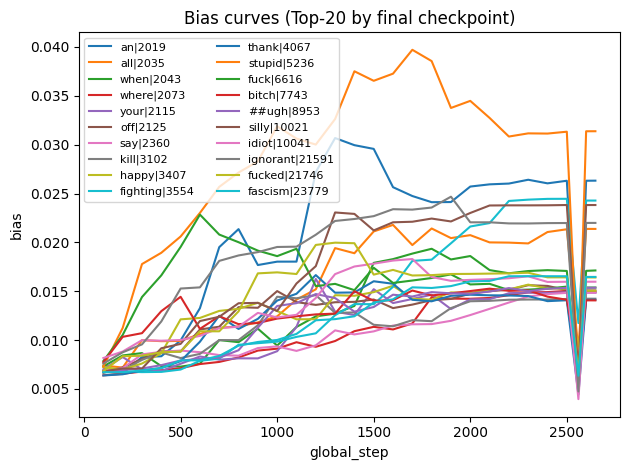

In [21]:
import os, re, math, csv
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from transformers import AutoTokenizer

RESULTS_DIR     = "./results"
MODEL_NAME      = "bert-base-uncased"
CSV_OUT         = "bias_top20_OLID_alltoken.csv"
TOPK            = 20
PER_HEAD_REDUCE = "mean"

checkpoints = []
for d in os.listdir(RESULTS_DIR):
    m = re.match(r"checkpoint-(\d+)", d)
    if m:
        checkpoints.append((int(m.group(1)), os.path.join(RESULTS_DIR,d)))
checkpoints.sort()

if not checkpoints:
    raise SystemExit("No checkpionts found")

# 2) 准备 tokenizer
tok = AutoTokenizer.from_pretrained(MODEL_NAME)
# 3 从模型里提取【V】的bias向量（兼容per head）
@torch.no_grad()
def get_bias_vector(model,reduce="mean"):
    W = model.bert.key_boost_table.weight
    if getattr(model.bert,"nonnegative",True):
        B = F.softplus(W)
    else:
        B = torch.tanh(W)
    if B.dim() == 2 and B.size(1) > 1:
        if reduce   == "mean"   : B = B.mean(dim=1)
        elif reduce == "max"    : B = B.max(dim=1).values
        elif reduce == "sum"    : B = B.sum(dim=1)
        else: raise ValueError("reduce must be something")
    else:
        B = B.view(-1)
    return B.cpu()

from MyBertSelfAttention_alltoken import MyBertForSequenceClassification
final_step, final_path = checkpoints[-1]
final_model = MyBertForSequenceClassification.from_pretrained(final_path)
final_model.eval()
B_final = get_bias_vector(final_model, reduce=PER_HEAD_REDUCE)
topk_vals, topk_ids = torch.topk(B_final,k=TOPK).values.tolist(), torch.topk(B_final, k=TOPK).indices.tolist()
tracked_ids     = list(map(int,topk_ids))
tracked_tokens  = [tok.convert_ids_to_tokens(tid) for tid in tracked_ids]
print("Top20:",list(zip(tracked_tokens,tracked_ids)))

# 5) 遍历每个 checkpoint，记录这些 token 的 bias
with open(CSV_OUT, "w", newline="", encoding="utf-8") as f:
    w = csv.writer(f)
    w.writerow(["global_step", "token_id", "token", "bias"])
    for step, path in checkpoints:
        model = MyBertForSequenceClassification.from_pretrained(path)
        model.eval()
        B = get_bias_vector(model, reduce=PER_HEAD_REDUCE)
        for tid in tracked_ids:
            w.writerow([step, tid, tok.convert_ids_to_tokens(tid), float(B[tid])])

print(f"已导出: {CSV_OUT}")

#draw the fig of bias
import pandas as pd
df = pd.read_csv(CSV_OUT)
plt.figure()
for (tid, token), g in df.groupby(["token_id","token"]):
    g = g.sort_values("global_step")
    plt.plot(g["global_step"], g["bias"], label=f"{token}|{tid}")
plt.xlabel("global_step")
plt.ylabel("bias")
plt.title("Bias curves (Top-20 by final checkpoint)")
plt.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

/home/fang/venv/lib/python3.12/site-packages/transformers/modeling_utils.py:1126: FutureWarning: The `device` argument is deprecated and will be removed in v5 of Transformers.
  warnings.warn(


accuracy: 0.7915407854984894
f1_macro: 0.7641779197521901
f1_micro: 0.7915407854984894
              precision    recall  f1-score   support

           0     0.8455    0.8436    0.8445      1777
           1     0.6823    0.6854    0.6838       871

    accuracy                         0.7915      2648
   macro avg     0.7639    0.7645    0.7642      2648
weighted avg     0.7918    0.7915    0.7917      2648



/home/fang/venv/lib/python3.12/site-packages/transformers/modeling_utils.py:1126: FutureWarning: The `device` argument is deprecated and will be removed in v5 of Transformers.
  warnings.warn(


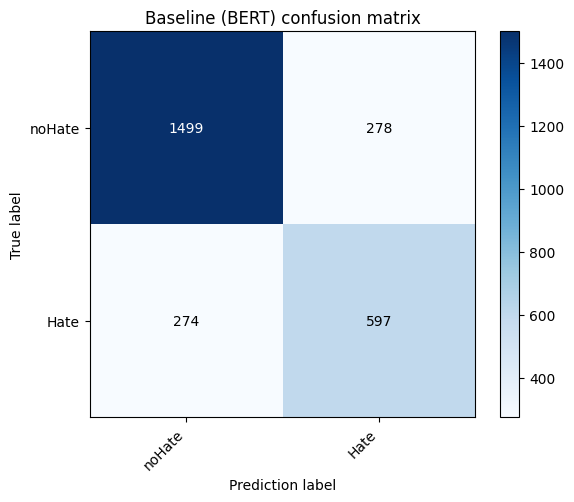

Accuracy : 0.7915407854984894
Macro-F1 : 0.7641779197521901
CM (rows=true, cols=pred):
 [[1499  278]
 [ 274  597]]


In [22]:
outputs = trainer.predict(test_dataset)   # 不需要 compute_metrics
logits = outputs.predictions[0] if isinstance(outputs.predictions, tuple) else outputs.predictions
labels = outputs.label_ids
preds  = logits.argmax(axis=-1)

from sklearn.metrics import accuracy_score, f1_score, classification_report
print("accuracy:", accuracy_score(labels, preds))
print("f1_macro:", f1_score(labels, preds, average="macro"))
print("f1_micro:", f1_score(labels, preds, average="micro"))
print(classification_report(labels, preds, digits=4))

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score

def eval_binary_and_plot_cm(trainer, eval_dataset, label_ids=(0, 1), label_names=("NOT", "OFF"),
                            title="Confusion matrix"):
    pred_out = trainer.predict(eval_dataset)
    logits = pred_out.predictions
    if isinstance(logits, tuple):
        logits = logits[0]

    y_pred = np.argmax(logits, axis=-1)
    y_true = pred_out.label_ids

    # 指标
    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")

    # 混淆矩阵（行=真实，列=预测）
    cm = confusion_matrix(y_true, y_pred, labels=list(label_ids))

    # 画图
    plt.figure(figsize=(6, 5))
    plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
    plt.title(title)
    plt.colorbar()

    ticks = np.arange(len(label_ids))
    plt.xticks(ticks, label_names, rotation=45, ha="right")
    plt.yticks(ticks, label_names)
    plt.ylabel("True label")
    plt.xlabel("Prediction label")

    thresh = cm.max() / 2.0 if cm.max() > 0 else 0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i, j]),
                     ha="center", va="center",
                     color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.show()

    print("Accuracy :", acc)
    print("Macro-F1 :", macro_f1)
    print("CM (rows=true, cols=pred):\n", cm)

    return {"accuracy": acc, "macro_f1": macro_f1, "confusion_matrix": cm}

# 用法：默认假设 0=NOT, 1=OFF
metrics = eval_binary_and_plot_cm(
    trainer,
    test_dataset,
    label_ids=(0, 1),
    label_names=("noHate", "Hate"),
    title="Baseline (BERT) confusion matrix"
)



### 3、与其他模型比较

#### 与ear+bert进行对比

In [28]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# baseline 模型
tokenizer = AutoTokenizer.from_pretrained("models/bert_baseline_olid")
baseline_model = AutoModelForSequenceClassification.from_pretrained(
    "models/bert_baseline_olid"
)


mybert_model = AutoModelForSequenceClassification.from_pretrained(
    "models/My_attention_bert_olid"
)

# EAR 模型
ear_model = AutoModelForSequenceClassification.from_pretrained(
    "models/bert_ear_olid"
)


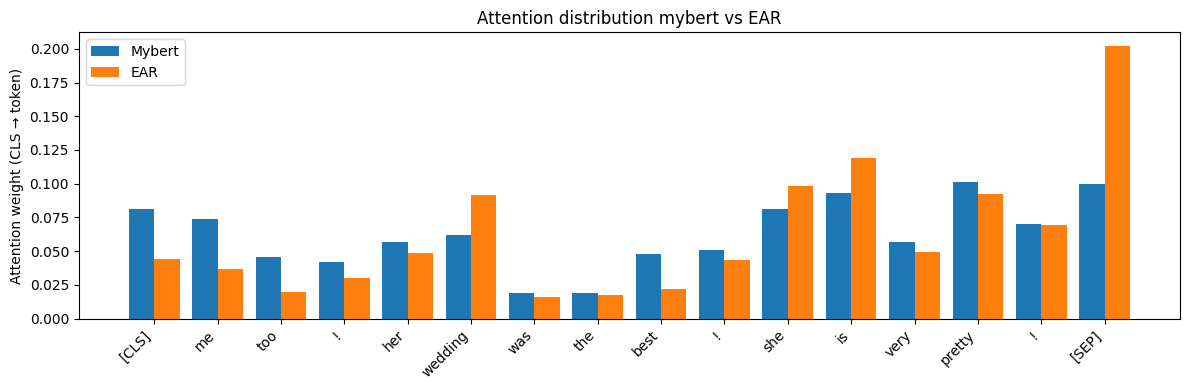

In [31]:
sentence = "Me too! Her wedding was the best! She is very pretty!"
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
mybert_model.to(device)
ear_model.to(device)

mybert_model.eval()
ear_model.eval()

# 编码
inputs = tokenizer(
    sentence,
    return_tensors="pt",
    truncation=True,
    padding=True
).to(device)

with torch.no_grad():
    mybert_outputs = mybert_model(**inputs, output_attentions=True)
    ear_outputs  = ear_model(**inputs,  output_attentions=True)

# attentions: tuple[num_layers], 每个是 [batch, heads, seq, seq]
mybert_attns = mybert_outputs.attentions
ear_attns  = ear_outputs.attentions

import numpy as np

def get_cls_attention(attentions, layer=-1):
    """
    attentions: tuple[num_layers] of [B, H, T, T]
    返回: cls_attn: [T]，表示 CLS 对每个 token 的注意力权重
    """
    att = attentions[layer]      # [B, H, T, T]
    att = att.mean(dim=1)        # 平均所有 head -> [B, T, T]
    cls_attn = att[0, 0, :]      # batch 0, CLS 位置行 [T]
    return cls_attn.detach().cpu().numpy()   # [T]

mybert_cls = get_cls_attention(mybert_attns, layer=-1)
ear_cls  = get_cls_attention(ear_attns,  layer=-1)

# 对应的 token 序列
tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

import numpy as np

def get_cls_attention(attentions, layer=-1):
    """
    attentions: tuple[num_layers] of [B, H, T, T]
    返回: cls_attn: [T]，表示 CLS 对每个 token 的注意力权重
    """
    att = attentions[layer]      # [B, H, T, T]
    att = att.mean(dim=1)        # 平均所有 head -> [B, T, T]
    cls_attn = att[0, 0, :]      # batch 0, CLS 位置行 [T]
    return cls_attn.detach().cpu().numpy()   # [T]

mybert_cls = get_cls_attention(mybert_attns, layer=-1)
ear_cls  = get_cls_attention(ear_attns,  layer=-1)

# 对应的 token 序列
tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])



import matplotlib.pyplot as plt
import numpy as np

x = np.arange(len(tokens))
width = 0.4

plt.figure(figsize=(12, 4))
plt.bar(x - width/2, mybert_cls, width, label="Mybert")
plt.bar(x + width/2, ear_cls,  width, label="EAR")

plt.xticks(x, tokens, rotation=45, ha="right")
plt.ylabel("Attention weight (CLS → token)")
plt.title("Attention distribution mybert vs EAR")
plt.legend()
plt.tight_layout()
plt.show()





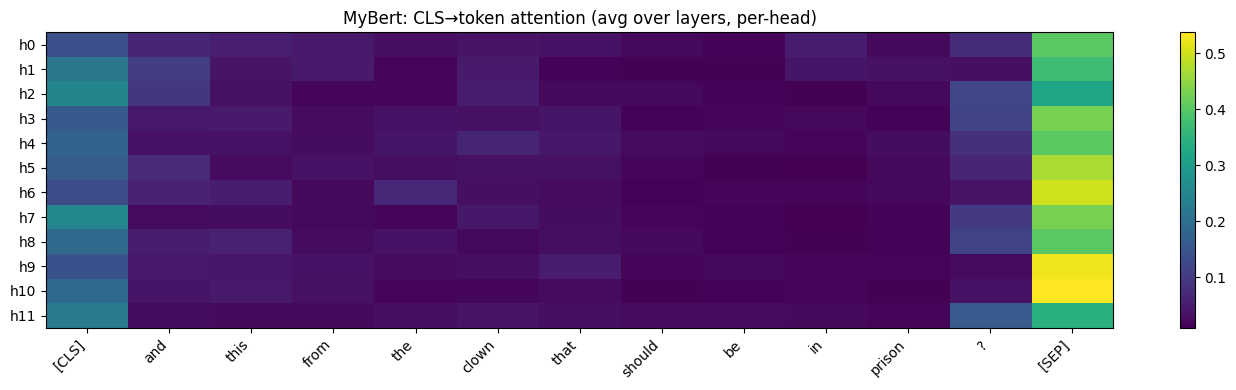

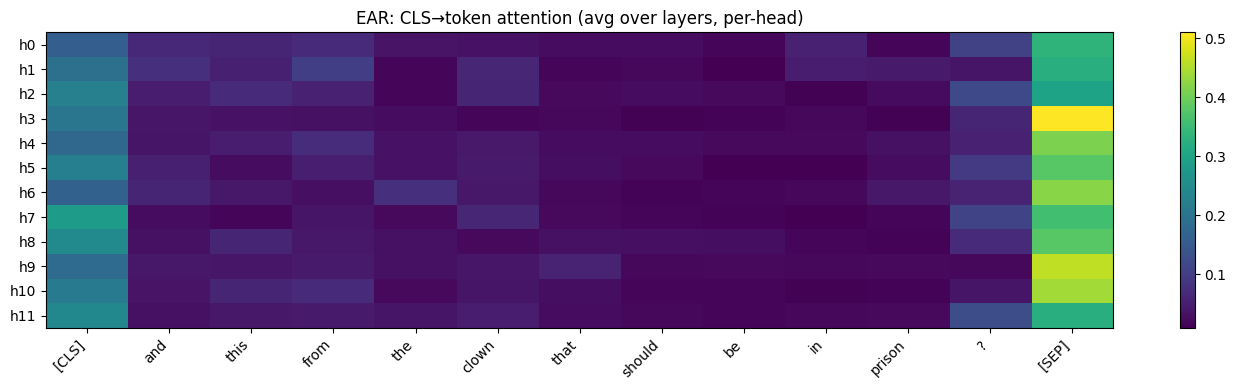

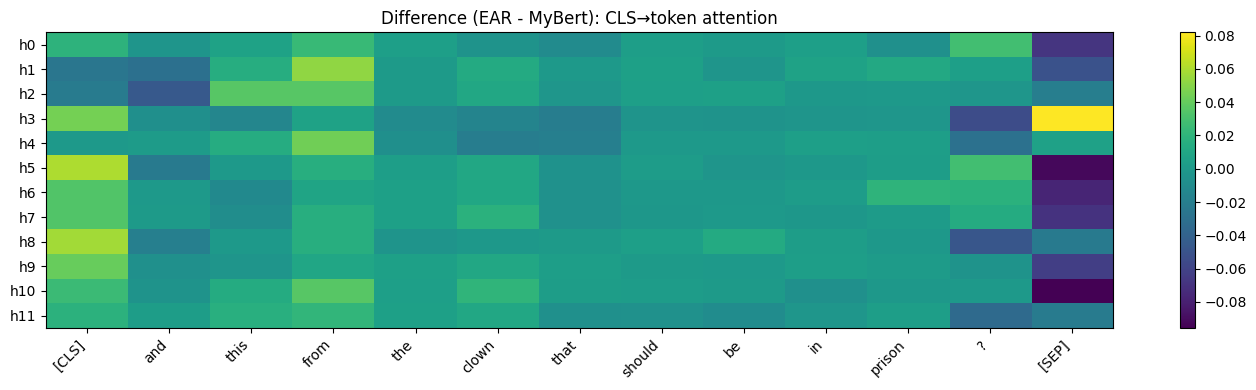

In [29]:
import torch

def cls_attn_per_head_avg_layers(attentions, layers="all"):
    """
    attentions: tuple[num_layers] of [B, H, T, T]
    layers:
      - "all"  -> 所有层平均
      - list   -> 例如 [0,1,2] 只平均这些层
      - int    -> 单层（不平均）
    返回:
      cls_by_head: [H, T]  (每个head一条 CLS->token 注意力分布，已对层做平均)
    """
    if layers == "all":
        layer_ids = list(range(len(attentions)))
    elif isinstance(layers, int):
        layer_ids = [layers]
    else:
        layer_ids = list(layers)

    # 每层取出 [B,H,T,T] -> 取 batch0, CLS(query=0) -> [H,T]
    per_layer = []
    for li in layer_ids:
        att = attentions[li]          # [B,H,T,T]
        cls = att[0, :, 0, :]         # [H,T]  (每个head保留)
        per_layer.append(cls)

    # [L,H,T] -> 对 L 平均 -> [H,T]
    cls_by_head = torch.stack(per_layer, dim=0).mean(dim=0)
    return cls_by_head.detach().cpu().numpy()

mybert_cls_heads = cls_attn_per_head_avg_layers(mybert_attns, layers="all")  # [H,T]
ear_cls_heads    = cls_attn_per_head_avg_layers(ear_attns,    layers="all")  # [H,T]

import matplotlib.pyplot as plt
import numpy as np

tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

diff = ear_cls_heads - mybert_cls_heads  # [H,T]

plt.figure(figsize=(14, 4))
plt.imshow(mybert_cls_heads, aspect="auto")
plt.yticks(range(mybert_cls_heads.shape[0]), [f"h{i}" for i in range(mybert_cls_heads.shape[0])])
plt.xticks(range(len(tokens)), tokens, rotation=45, ha="right")
plt.title("MyBert: CLS→token attention (avg over layers, per-head)")
plt.colorbar()
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 4))
plt.imshow(ear_cls_heads, aspect="auto")
plt.yticks(range(ear_cls_heads.shape[0]), [f"h{i}" for i in range(ear_cls_heads.shape[0])])
plt.xticks(range(len(tokens)), tokens, rotation=45, ha="right")
plt.title("EAR: CLS→token attention (avg over layers, per-head)")
plt.colorbar()
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 4))
plt.imshow(diff, aspect="auto")
plt.yticks(range(diff.shape[0]), [f"h{i}" for i in range(diff.shape[0])])
plt.xticks(range(len(tokens)), tokens, rotation=45, ha="right")
plt.title("Difference (EAR - MyBert): CLS→token attention")
plt.colorbar()
plt.tight_layout()
plt.show()
